In [1]:
!pip install umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import umap.umap_ as umap_lib
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

2026-04-23 07:42:56.640464: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776930176.878483      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776930176.944877      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776930177.516408      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776930177.516462      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776930177.516465      55 computation_placer.cc:177] computation placer alr

Using device: cpu


## 1. Data Loading & Preprocessing

In [15]:
# Load English dataset
ds = pd.read_csv('/kaggle/input/datasets/mdtamim26301/sample10k/sample_10k_lyrics.csv')
df1 = ds[ds['language'] == 'en']
ds_5k = df1.sample(n=5000, random_state=42)

# Load Bangla dataset
ds_b = pd.read_csv('/kaggle/input/datasets/shakirulhasan/bangla-song-lyrics/BanglaSongLyrics.csv')

# Keep only lyrics column
eng_lyrics = ds_5k[['lyrics']].reset_index(drop=True)
ban_lyrics = ds_b[['lyrics']].reset_index(drop=True)

# Combine
df = pd.concat([eng_lyrics, ban_lyrics], ignore_index=True)
print('Dataset shape:', df.shape)

Dataset shape: (9105, 1)


In [16]:
def clean_lyrics(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'\n', ' ', text)
    # Keep English + Bangla
    text = re.sub(r'[^a-zA-Z\u0980-\u09FF\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    return text

df_clean = df['lyrics'].apply(clean_lyrics)
print('Sample cleaned lyric:', df_clean.iloc[0][:120])

Sample cleaned lyric: you know that i m waiting for my lucky day to begin you know i m waiting for my lucky day to begin well i can t go on lo


In [17]:
vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=5,
    max_df=0.8
)

X = vectorizer.fit_transform(df_clean)
X_tensor = torch.tensor(X.toarray(), dtype=torch.float32).to(device)
input_dim = X_tensor.shape[1]
print('Input dimension:', input_dim)

dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

Input dimension: 10000


## 2. Upgraded VAE Architecture

Two improvements over the baseline:
- **Deeper encoder/decoder**: 3-layer MLP with widths 512 → 256 → 128 (vs. single 128-unit layer before)
- **Larger latent space**: tested at dim=8 (baseline), dim=16, and dim=32
- **BatchNorm + Dropout(0.2)** added to each hidden layer for regularisation

In [18]:
class DeepVAE(nn.Module):
    """
    Deeper VAE with 3-layer encoder/decoder.
    Architecture:
        Encoder: input_dim -> 512 -> 256 -> 128 -> (mu, logvar) of size latent_dim
        Decoder: latent_dim -> 128 -> 256 -> 512 -> input_dim
    Each hidden layer uses BatchNorm + ReLU + Dropout(0.2).
    """
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()

        # ---- Encoder ----
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # ---- Decoder ----
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

print('DeepVAE class defined.')

DeepVAE class defined.


## 3. Training Helper

In [19]:
def vae_loss(recon_x, x, mu, logvar):
    recon = nn.MSELoss()(recon_x, x)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl


def train_vae(model, dataloader, epochs=50, lr=1e-3):
    """Train a VAE and return per-epoch losses."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = []
    model.train()
    for epoch in range(1, epochs + 1):
        total = 0.0
        for (x,) in dataloader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss = vae_loss(recon, x, mu, logvar)
            loss.backward()
            optimizer.step()
            total += loss.item()
        history.append(total)
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}  Loss: {total:.4f}')
    return history


def get_latent(model, X_tensor):
    """Extract mean latent vectors (no gradient)."""
    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(X_tensor.to(device))
    return mu.cpu().numpy()


def cluster_and_score(Z, n_clusters=5, label=''):
    """KMeans + Silhouette + CH + Davies-Bouldin."""
    km     = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(Z)
    sil    = silhouette_score(Z, labels)
    ch     = calinski_harabasz_score(Z, labels)
    db     = davies_bouldin_score(Z, labels)
    print(f'{label}')
    print(f'  Silhouette:      {sil:.5f}  (higher better)')
    print(f'  Calinski-Harabasz: {ch:.1f}  (higher better)')
    print(f'  Davies-Bouldin:  {db:.5f}  (lower  better)')
    return labels, sil, ch, db

print('Helpers ready.')

Helpers ready.


## 4. Experiment A — Latent dim = 8  (Baseline reproduction)

In [20]:
print('=== Training DeepVAE  latent_dim=8 ===')
model_8 = DeepVAE(input_dim=input_dim, latent_dim=8).to(device)
loss_8  = train_vae(model_8, dataloader, epochs=50)
Z8      = get_latent(model_8, X_tensor)
labels_8, sil_8, ch_8, db_8 = cluster_and_score(Z8, n_clusters=5, label='DeepVAE latent_dim=8')

=== Training DeepVAE  latent_dim=8 ===
  Epoch  10  Loss: 0.0106
  Epoch  20  Loss: 0.0064
  Epoch  30  Loss: 0.0058
  Epoch  40  Loss: 0.0055
  Epoch  50  Loss: 0.0054
DeepVAE latent_dim=8
  Silhouette:      0.65632  (higher better)
  Calinski-Harabasz: 78312.1  (higher better)
  Davies-Bouldin:  0.55171  (lower  better)


## 5. Experiment B — Latent dim = 16

In [21]:
print('=== Training DeepVAE  latent_dim=16 ===')
model_16 = DeepVAE(input_dim=input_dim, latent_dim=16).to(device)
loss_16  = train_vae(model_16, dataloader, epochs=50)
Z16      = get_latent(model_16, X_tensor)
labels_16, sil_16, ch_16, db_16 = cluster_and_score(Z16, n_clusters=5, label='DeepVAE latent_dim=16')

=== Training DeepVAE  latent_dim=16 ===
  Epoch  10  Loss: 0.0123
  Epoch  20  Loss: 0.0073
  Epoch  30  Loss: 0.0059
  Epoch  40  Loss: 0.0054
  Epoch  50  Loss: 0.0052
DeepVAE latent_dim=16
  Silhouette:      0.63533  (higher better)
  Calinski-Harabasz: 16063.8  (higher better)
  Davies-Bouldin:  1.18614  (lower  better)


## 6. Experiment C — Latent dim = 32

In [22]:
print('=== Training DeepVAE  latent_dim=32 ===')
model_32 = DeepVAE(input_dim=input_dim, latent_dim=32).to(device)
loss_32  = train_vae(model_32, dataloader, epochs=50)
Z32      = get_latent(model_32, X_tensor)
labels_32, sil_32, ch_32, db_32 = cluster_and_score(Z32, n_clusters=5, label='DeepVAE latent_dim=32')

=== Training DeepVAE  latent_dim=32 ===
  Epoch  10  Loss: 0.0120
  Epoch  20  Loss: 0.0070
  Epoch  30  Loss: 0.0055
  Epoch  40  Loss: 0.0052
  Epoch  50  Loss: 0.0049
DeepVAE latent_dim=32
  Silhouette:      0.29091  (higher better)
  Calinski-Harabasz: 50274.0  (higher better)
  Davies-Bouldin:  1.18292  (lower  better)


## 7. Baseline — PCA + KMeans (for comparison)

In [23]:
pca      = PCA(n_components=8)
X_pca    = pca.fit_transform(X.toarray())
labels_pca, sil_pca, ch_pca, db_pca = cluster_and_score(X_pca, n_clusters=8, label='PCA (8 components, k=8)')

PCA (8 components, k=8)
  Silhouette:      0.30036  (higher better)
  Calinski-Harabasz: 5531.6  (higher better)
  Davies-Bouldin:  1.12190  (lower  better)


## 8. Summary Comparison Table

In [24]:
results = pd.DataFrame({
    'Model':              ['Shallow VAE (orig)', 'DeepVAE dim=8', 'DeepVAE dim=16', 'DeepVAE dim=32', 'PCA baseline'],
    'Silhouette':         [0.307,  sil_8,  sil_16,  sil_32,  sil_pca],
    'Calinski-Harabasz':  [9172.1, ch_8,   ch_16,   ch_32,   ch_pca],
    'Davies-Bouldin':     [None,   db_8,   db_16,   db_32,   db_pca],
    'Latent Dim':         [8,      8,      16,      32,      'N/A (PCA 8 comp)'],
    'Depth':              ['1 layer','3 layers','3 layers','3 layers','—'],
})

pd.set_option('display.float_format', '{:.4f}'.format)
print(results.to_string(index=False))

             Model  Silhouette  Calinski-Harabasz  Davies-Bouldin       Latent Dim    Depth
Shallow VAE (orig)      0.3070          9172.1000             NaN                8  1 layer
     DeepVAE dim=8      0.6563         78312.1172          0.5517                8 3 layers
    DeepVAE dim=16      0.6353         16063.7832          1.1861               16 3 layers
    DeepVAE dim=32      0.2909         50274.0195          1.1829               32 3 layers
      PCA baseline      0.3004          5531.6285          1.1219 N/A (PCA 8 comp)        —


## 9. Training Loss Curves — All Three Experiments

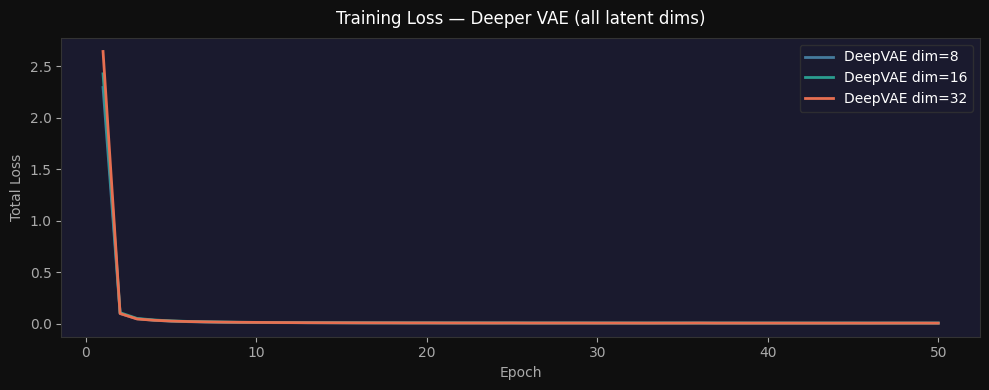

Loss curves saved.


In [25]:
colors = {'dim=8': '#457b9d', 'dim=16': '#2a9d8f', 'dim=32': '#e76f51'}

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

epochs_range = list(range(1, 51))
ax.plot(epochs_range, loss_8,  label='DeepVAE dim=8',  color=colors['dim=8'],  linewidth=2)
ax.plot(epochs_range, loss_16, label='DeepVAE dim=16', color=colors['dim=16'], linewidth=2)
ax.plot(epochs_range, loss_32, label='DeepVAE dim=32', color=colors['dim=32'], linewidth=2)

ax.set_xlabel('Epoch', color='#aaaaaa')
ax.set_ylabel('Total Loss', color='#aaaaaa')
ax.set_title('Training Loss — Deeper VAE (all latent dims)', color='white', pad=10)
legend = ax.legend(facecolor='#1a1a2e', edgecolor='#333333', labelcolor='white')
plt.tight_layout()
plt.savefig('loss_curves_deep_vae.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Loss curves saved.')

## 10. UMAP + t-SNE Visualisation — Best Performing Model

Best model: DeepVAE dim=8  (Silhouette=0.65632)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


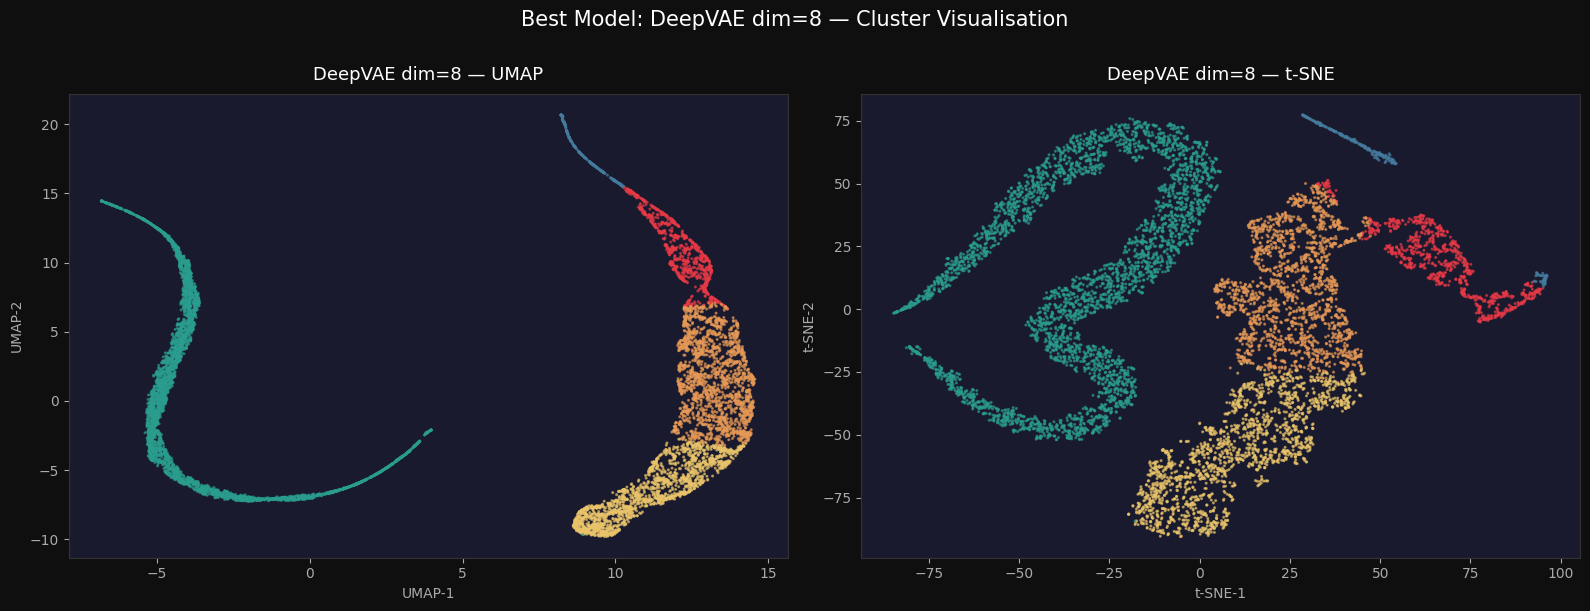

Visualisation saved.


In [26]:
# Pick best model by Silhouette
best_scores = {'dim=8': sil_8, 'dim=16': sil_16, 'dim=32': sil_32}
best_name   = max(best_scores, key=best_scores.get)
best_Z      = {'dim=8': Z8, 'dim=16': Z16, 'dim=32': Z32}[best_name]
best_labels = {'dim=8': labels_8, 'dim=16': labels_16, 'dim=32': labels_32}[best_name]
print(f'Best model: DeepVAE {best_name}  (Silhouette={best_scores[best_name]:.5f})')

import matplotlib.colors as mcolors
palette = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#e69956']
cmap    = mcolors.ListedColormap(palette)

reducer   = umap_lib.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
Z_umap    = reducer.fit_transform(best_Z)

tsne_mdl  = TSNE(n_components=2, random_state=42)
Z_tsne    = tsne_mdl.fit_transform(best_Z)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

sc1 = axes[0].scatter(Z_umap[:, 0], Z_umap[:, 1], c=best_labels, cmap=cmap, s=1.5, alpha=0.6)
axes[0].set_title(f'DeepVAE {best_name} — UMAP', color='white', fontsize=13, pad=10)
axes[0].set_xlabel('UMAP-1', color='#aaaaaa')
axes[0].set_ylabel('UMAP-2', color='#aaaaaa')

sc2 = axes[1].scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=best_labels, cmap=cmap, s=1.5, alpha=0.6)
axes[1].set_title(f'DeepVAE {best_name} — t-SNE', color='white', fontsize=13, pad=10)
axes[1].set_xlabel('t-SNE-1', color='#aaaaaa')
axes[1].set_ylabel('t-SNE-2', color='#aaaaaa')

plt.suptitle(f'Best Model: DeepVAE {best_name} — Cluster Visualisation', color='white', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f'deep_vae_{best_name}_umap_tsne.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Visualisation saved.')

## 11. Qualitative Cluster Inspection (Best Model)

In [27]:
n_clusters   = 5
feature_names = np.array(vectorizer.get_feature_names_out())
X_arr        = X.toarray()

print('=' * 65)
print(f'TOP 15 TF-IDF WORDS PER CLUSTER  (DeepVAE {best_name})')
print('=' * 65)

for c in range(n_clusters):
    mask = best_labels == c
    mean_tfidf = X_arr[mask].mean(axis=0)
    top_idx    = mean_tfidf.argsort()[::-1][:15]
    top_words  = feature_names[top_idx].tolist()
    print(f'\nCluster {c}  ({mask.sum():,} songs)')
    print('  ' + ',  '.join(top_words))

print('\n')
print('=' * 65)
print('CLUSTER SIZE SUMMARY')
print('=' * 65)
unique, counts = np.unique(best_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    pct = cnt / len(best_labels) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c}: {cnt:6,} songs  ({pct:.1f}%)  {bar}')

TOP 15 TF-IDF WORDS PER CLUSTER  (DeepVAE dim=8)

Cluster 0  (867 songs)
   th,  the,   the,  he ,  the ,   the ,   i ,  nd ,  ng ,  ing,  ing ,   an,  and,  in ,   yo

Cluster 1  (4,102 songs)
  ার ,  রে ,   আম,  না ,  ের ,  মার,   না,  মি ,  লে ,  ায় ,  মার ,   তো,  নে ,   না ,  আমা

Cluster 2  (1,928 songs)
   th,   yo,   you,  you,   i ,   you ,  you ,  ou ,  the,   the,  he ,  me ,  ng ,  the ,   the 

Cluster 3  (258 songs)
   th,  the,   the,  he ,  the ,   the ,  nd ,   an,  ed ,  and,   of,  and ,  of ,   of ,   to

Cluster 4  (1,950 songs)
   th,   i ,  the,   the,   yo,   you,  you,  he ,  you ,   you ,  the ,  ou ,   the ,  ng ,  nd 


CLUSTER SIZE SUMMARY
  Cluster 0:    867 songs  (9.5%)  ████
  Cluster 1:  4,102 songs  (45.1%)  ██████████████████████
  Cluster 2:  1,928 songs  (21.2%)  ██████████
  Cluster 3:    258 songs  (2.8%)  █
  Cluster 4:  1,950 songs  (21.4%)  ██████████
